In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_excel('../data/personal finance data.xlsx')
df.head()

,Date / Time,Mode,Category,Sub category,Income/Expense,Debit/Credit
0,2021-01-01 21:45:00,CUB - online payment,Allowance,From dad,Income,8000.0
1,2021-01-01 21:46:00,CUB - online payment,Food,Snacks,Expense,85.0
2,2021-01-03 18:21:00,CUB - online payment,Other,From dad,Income,500.0
3,2021-01-03 18:22:00,CUB - online payment,Household,Stuffs,Expense,6667.0
4,2021-01-03 18:56:00,CUB - online payment,Transportation,Metro,Expense,30.0


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date / Time     225 non-null    datetime64[ns]
 1   Mode            225 non-null    object        
 2   Category        225 non-null    object        
 3   Sub category    225 non-null    object        
 4   Income/Expense  225 non-null    object        
 5   Debit/Credit    225 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 10.7+ KB


In [37]:
df.describe()

,Date / Time,Debit/Credit
count,225,225.000000
mean,2021-07-06 02:51:24.266666752,3768.890133
min,2021-01-01 21:45:00,8.000000
25%,2021-02-21 15:40:00,80.000000
50%,2021-06-22 16:41:00,200.000000
75%,2021-11-28 19:59:00,700.000000
max,2021-12-30 14:10:00,55530.000000
std,NaN,12353.959576


In [38]:
df.isnull().sum()

Date / Time       0
Mode              0
Category          0
Sub category      0
Income/Expense    0
Debit/Credit      0
dtype: int64

In [39]:
df.head()

,Date / Time,Mode,Category,Sub category,Income/Expense,Debit/Credit
0,2021-01-01 21:45:00,CUB - online payment,Allowance,From dad,Income,8000.0
1,2021-01-01 21:46:00,CUB - online payment,Food,Snacks,Expense,85.0
2,2021-01-03 18:21:00,CUB - online payment,Other,From dad,Income,500.0
3,2021-01-03 18:22:00,CUB - online payment,Household,Stuffs,Expense,6667.0
4,2021-01-03 18:56:00,CUB - online payment,Transportation,Metro,Expense,30.0


In [40]:
df.columns = ['Date', 'Mode', 'Category', 'Sub_Category', 'Type', 'Amount']
df.head()

,Date,Mode,Category,Sub_Category,Type,Amount
0,2021-01-01 21:45:00,CUB - online payment,Allowance,From dad,Income,8000.0
1,2021-01-01 21:46:00,CUB - online payment,Food,Snacks,Expense,85.0
2,2021-01-03 18:21:00,CUB - online payment,Other,From dad,Income,500.0
3,2021-01-03 18:22:00,CUB - online payment,Household,Stuffs,Expense,6667.0
4,2021-01-03 18:56:00,CUB - online payment,Transportation,Metro,Expense,30.0


In [41]:
df['Date'] = pd.to_datetime(df['Date'])

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          225 non-null    datetime64[ns]
 1   Mode          225 non-null    object        
 2   Category      225 non-null    object        
 3   Sub_Category  225 non-null    object        
 4   Type          225 non-null    object        
 5   Amount        225 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 10.7+ KB


In [43]:
df['Amount'] = df.apply(
    lambda x: x['Amount'] if x['Type'] == 'Income' else -x['Amount'],
    axis=1
)

In [44]:
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Year'] = df['Date'].dt.year

In [45]:
df.isnull().sum()

Date            0
Mode            0
Category        0
Sub_Category    0
Type            0
Amount          0
Month           0
Day             0
Year            0
dtype: int64

In [46]:
df.head()

,Date,Mode,Category,Sub_Category,Type,Amount,Month,Day,Year
0,2021-01-01 21:45:00,CUB - online payment,Allowance,From dad,Income,8000.0,1,1,2021
1,2021-01-01 21:46:00,CUB - online payment,Food,Snacks,Expense,-85.0,1,1,2021
2,2021-01-03 18:21:00,CUB - online payment,Other,From dad,Income,500.0,1,3,2021
3,2021-01-03 18:22:00,CUB - online payment,Household,Stuffs,Expense,-6667.0,1,3,2021
4,2021-01-03 18:56:00,CUB - online payment,Transportation,Metro,Expense,-30.0,1,3,2021


In [47]:
df.columns

Index(['Date', 'Mode', 'Category', 'Sub_Category', 'Type', 'Amount', 'Month',
       'Day', 'Year'],
      dtype='object')

In [48]:
expense_data = df[df['Type'] == 'Expense']
category_spend = expense_data.groupby('Category')['Amount'].sum().sort_values()

category_spend

Category
Household        -54810.00
Other            -28887.00
Food             -24607.76
Transportation   -15873.80
Education        -14000.00
Apparel           -8396.00
apparel           -3278.72
Name: Amount, dtype: float64

In [49]:
category_percent = (category_spend / category_spend.sum()) * 100
category_percent

Category
Household         36.575776
Other             19.276855
Food              16.421235
Transportation    10.592895
Education          9.342472
Apparel            5.602814
apparel            2.187953
Name: Amount, dtype: float64

In [50]:
monthly_expense = df[df['Type'] == 'Expense'].groupby('Month')['Amount'].sum()
monthly_expense

Month
1    -13244.15
2    -17200.95
3    -11145.00
4    -20739.00
5     -8945.72
6    -12651.81
7     -8694.00
8     -5711.00
9     -6662.00
10   -13521.00
11    -7312.90
12   -24025.75
Name: Amount, dtype: float64

In [51]:
monthly_summary = df.groupby(['Month', 'Type'])['Amount'].sum().unstack()
monthly_summary['Savings'] = monthly_summary['Income'] + monthly_summary['Expense']

monthly_summary

Type,Expense,Income,Savings
Month,,,
1,-13244.15,67975.0,54730.85
2,-17200.95,55000.0,37799.05
3,-11145.00,56641.0,45496.00
4,-20739.00,55000.0,34261.00
5,-8945.72,55000.0,46054.28
6,-12651.81,55440.0,42788.19
7,-8694.00,55300.0,46606.00
8,-5711.00,58010.0,52299.00
9,-6662.00,55270.0,48608.00


In [52]:
df[df['Type'] == 'Expense'].sort_values(by='Amount').head(10)

,Date,Mode,Category,Sub_Category,Type,Amount,Month,Day,Year
81,2021-04-01 22:11:00,CUB - online payment,Education,Arrear and reval fee,Expense,-14000.0,4,1,2021
197,2021-12-19 15:51:00,CUB - online payment,Other,To siva,Expense,-10000.0,12,19,2021
150,2021-10-18 21:01:00,CUB - online payment,Other,To kumara,Expense,-10000.0,10,18,2021
182,2021-12-02 16:04:00,CUB - online payment,Household,Mirror,Expense,-7770.0,12,2,2021
3,2021-01-03 18:22:00,CUB - online payment,Household,Stuffs,Expense,-6667.0,1,3,2021
86,2021-04-22 06:33:00,CUB - online payment,Household,Stuffs,Expense,-5180.0,4,22,2021
98,2021-05-22 06:33:00,CUB - online payment,Household,Stuffs,Expense,-5120.0,5,22,2021
75,2021-03-22 06:33:00,CUB - online payment,Household,Stuffs,Expense,-5120.0,3,22,2021
116,2021-07-22 06:33:00,CUB - online payment,Household,Stuffs,Expense,-4620.0,7,22,2021
122,2021-08-01 13:38:00,CUB - online payment,Household,Rent,Expense,-4580.0,8,1,2021


In [61]:
sns.set_style("whitegrid")

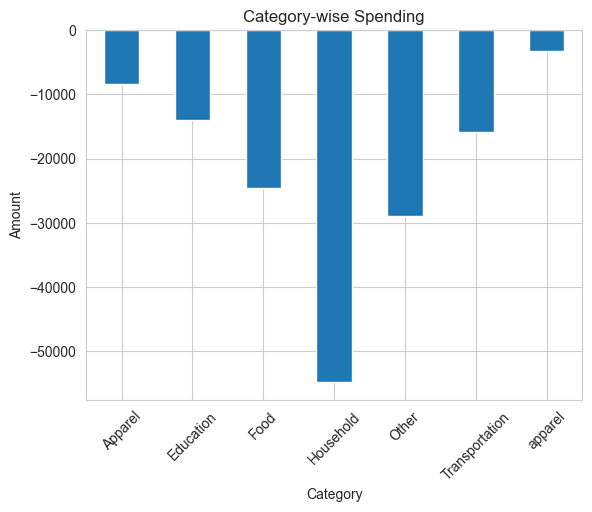

In [83]:
category_spend = df[df['Type'] == 'Expense'].groupby('Category')['Amount'].sum()

category_spend.plot(kind='bar')
plt.title("Category-wise Spending")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.savefig('../visuals/category_spending.png')
plt.show()

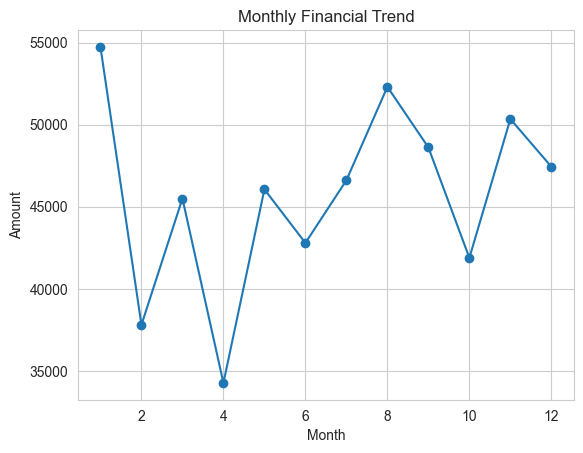

In [85]:
monthly = df.groupby('Month')['Amount'].sum()

monthly.plot(kind='line', marker='o')
plt.title("Monthly Financial Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.savefig('../visuals/monthy_trend.png')
plt.show()


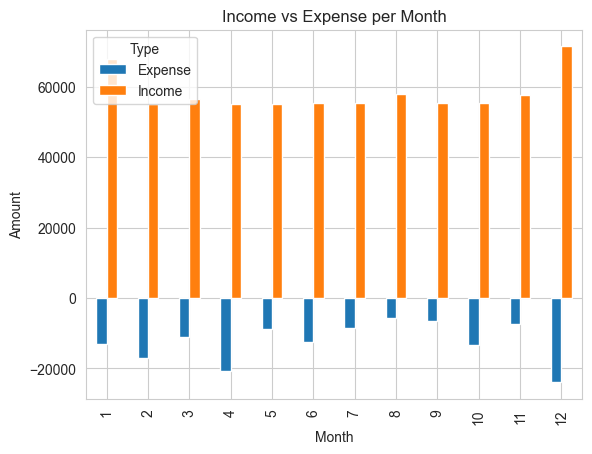

In [86]:
monthly_ie = df.groupby(['Month', 'Type'])['Amount'].sum().unstack()

monthly_ie.plot(kind='bar')
plt.title("Income vs Expense per Month")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.savefig('../visuals/income_vs_expense.png')
plt.show()

In [78]:
from sklearn.linear_model import LinearRegression

# Only expense data
expense_df = df[df['Type'] == 'Expense']

# Group by month
monthly_expense = expense_df.groupby('Month')['Amount'].sum().reset_index()

monthly_expense

,Month,Amount
0,1,-13244.15
1,2,-17200.95
2,3,-11145.00
3,4,-20739.00
4,5,-8945.72
5,6,-12651.81
6,7,-8694.00
7,8,-5711.00
8,9,-6662.00
9,10,-13521.00


In [79]:
X = monthly_expense[['Month']]
y = monthly_expense['Amount']

In [80]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [81]:
prediction = model.predict([[13]])
print("Predicted Expense for Month 13:", prediction)

Predicted Expense for Month 13: [-11628.45924242]


c:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


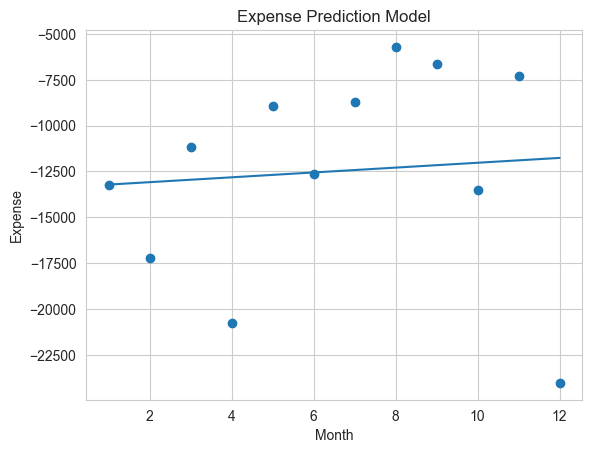

In [82]:
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.title("Expense Prediction Model")
plt.xlabel("Month")
plt.ylabel("Expense")
plt.show()